### There are several ways to establish connection to local postgresql db but we will use pandas and sqlalchemy libraries

### To install it RUN THE NEXT CELL BY CLICKING ON IT AND SHIFT+ENTER or click RUN BUTTON ABOVE

In [1]:
!pip install pandas sqlalchemy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### As now we have proper libraries we can import and use them 

### Execute the following cell 

In [2]:
import pandas as pd
from sqlalchemy import create_engine

def connect_to_db(dbname: str, user: str, password: str, host: str = "localhost", port: str = "5432"):
    try:
        conn_str = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
        engine = create_engine(conn_str)
        print(f"Engine created for database: {dbname}")
        return engine
    except Exception as e:
        print(f"Error creating engine for {dbname}: {e}")
        return None


### in previous cell we creted connect_to_db function which we can reuse to connect to both of our DBs, we just need to provide propper attributers. 

### In the next cell you can find example of establishing connection to SRC DB and reading data from s1.s1_channels into separate pandas dataframe

### Execute the following cell 

In [4]:
src_engine = connect_to_db(
    dbname="dwh_src_hw_db",
    user="postgres",
    password="4862"
)

s1_channels_df = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_df

Engine created for database: dwh_src_hw_db


,channel_id,channel_name,channel_location
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
153,154,YAOBAO.COM,Internet
154,155,CATALOG.ONLINER.BY,Internet
155,156,5ELEMENT.BY,Internet
156,157,ALLEGRO.PL,Internet


 ## YOUR TASK IS TO ESTABLISH SEPARATE 

 trg_engine 

 ## and conect to dwh_hw_db in the next cell

In [5]:
trg_engine = connect_to_db(
    dbname="dwh_hw_db",
    user="postgres",
    password="4862"
)

lnd_s1_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_channels", trg_engine)
lnd_s1_channels_df

Engine created for database: dwh_hw_db


,channel_id,channel_name,channellocation
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
151,152,EBAY.COM,N/A - Internet
152,153,ALIEXPRESS.COM,N/A - Internet
153,154,YAOBAO.COM,N/A - Internet
154,155,CATALOG-ONLINER.BY,N/A - Internet


#### AS we have 2 DFs with data from 2 tables we need to compare them. To do so we can create separate DF s1_channels_comparison_df

### Execute the following cell 

In [6]:
s1_channels_comparison_df = s1_channels_df.merge(
    lnd_s1_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_channels_comparison_df

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge
0,1,STORE - 1,621 Hovde Circle,STORE - 1,621 Hovde Circle,both
1,10,STORE - 10,6840 Pennsylvania Terrace,STORE - 10,6840 Pennsylvania Terrace,both
2,100,STORE - 100,72760 Helena Avenue,STORE - 100,72760 Helena Avenue,both
3,101,STORE - 101,40 Lyons Place,STORE - 101,40 Lyons Place,both
4,102,STORE - 102,04 Ludington Pass,STORE - 102,04 Ludington Pass,both
...,...,...,...,...,...,...
153,95,STORE - 95,6354 Lukken Circle,STORE - 95,6354 Lukken Circle,both
154,96,STORE - 96,1 Lighthouse Bay Way,STORE - 96,1 Lighthouse Bay Way,both
155,97,STORE - 97,03 Moland Parkway,STORE - 97,03 Moland Parkway,both
156,98,STORE - 98,24450 Kim Center,STORE - 98,24450 Kim Center,both


### Since we use indicator=True in the merge, pandas automatically provides the _merge column with values left_only, right_only, or both for the ID values.

### However, we want to make the statuses more meaningful, similar to what we did in SQL and also check for differences in other attributes, not just IDs.
### For this reason, I have prepared a separate function specifically for computing reconciliation_status for the channels table.

### Execute the following cell 

In [7]:
def get_s1_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['channel_location'] != row['channellocation']:
        mismatches.append('channel_location')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

### Since this function expects a single row as input, we can apply it to our s1_channel_comparison_df and create a new column to store the adapted reconciliation statuses.

### Execute the following cell 


In [8]:
s1_channels_comparison_df['reconciliation_status'] = s1_channels_comparison_df.apply(get_s1_channels_reconciliation_status, axis=1)

### And now, let’s keep only the rows with discrepancies (i.e., excluding rows where everything matches).

In [10]:
s1_channels_issues_df = s1_channels_comparison_df[s1_channels_comparison_df['reconciliation_status'] != 'Match']
display(s1_channels_issues_df.head(20))

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge,reconciliation_status
58,151,AMAZON.COM,Internet,AMAZON.COM,N/A - Internet,both,Mismatch in channel_location
59,152,EBAY.COM,Internet,EBAY.COM,N/A - Internet,both,Mismatch in channel_location
60,153,ALIEXPRESS.COM,Internet,ALIEXPRESS.COM,N/A - Internet,both,Mismatch in channel_location
61,154,YAOBAO.COM,Internet,YAOBAO.COM,N/A - Internet,both,Mismatch in channel_location
62,155,CATALOG.ONLINER.BY,Internet,CATALOG-ONLINER.BY,N/A - Internet,both,"Mismatch in channel_name, channel_location"
63,156,5ELEMENT.BY,Internet,5ELEMENT.BY,N/A - Internet,both,Mismatch in channel_location
64,157,ALLEGRO.PL,Internet,NaN,NaN,left_only,Only in source
65,158,AMAZON.COM,Internet,NaN,NaN,left_only,Only in source


# Task: Reconcile all other table pairs from SRC and LND, similar to what we did for the channels table.

## Instructions:

### Tables to compare:

###### s1.s1_products → lnd.lnd_s1_products
###### s1.s1_sales → lnd.lnd_s1_sales
###### s2.s2_channels → lnd.lnd_s2_channels
###### s2.s2_client_sales → lnd.lnd_s2_client_sales
###### s2.s2_clients → lnd.lnd_s2_clients
###### s2.s2_locations → lnd.lnd_s2_locations

## For each table pair:

### 1. Load the SRC and LND tables into pandas DataFrames.
### 2. Perform a full outer merge on the primary key column(s).
### 3. Apply a function like get_reconciliation_status(row) to classify each row into statuses:
###### 'Only in source'
###### 'Only in landing'
###### 'Mismatch in <column_name>'
###### 'Match'

### Keep only rows with issues (statuses != 'Match').

## 4. Create a consolidated result DataFrame with the following columns:

###### table_name	Name of the table being compared
###### key_column	Primary key column used for reconciliation
###### src_id	ID value from source table
###### trg_id	ID value from landing table
###### reconciliation_status	Status of the row (Only in source, Only in landing, etc.)

## 5. Populate the final result DataFrame with all discrepancies from all table comparisons.

### Tips / Methods:

### Use pd.merge(..., how='outer', indicator=True) to combine SRC and LND tables.
### Apply your reconciliation status function row-wise with df.apply(..., axis=1).
### Filter only rows with issues using df[df['reconciliation_status'] != 'Match'].
### Concatenate multiple issues_df DataFrames using pd.concat([...], ignore_index=True) to create the final consolidated DataFrame.

In [12]:
#YOUR CODE HERE AND BELOW
def get_reconciliation_status(row, compare_cols):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    mismatches = []
    for col in compare_cols:
        if row[f'{col}_src'] != row[f'{col}_lnd']:
            mismatches.append(col)
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    return 'Match'


def make_ids(row, key_cols):
    idval = '-'.join(str(row[c]) for c in key_cols)
    if row['_merge'] == 'left_only':
        return pd.Series([idval, None])
    elif row['_merge'] == 'right_only':
        return pd.Series([None, idval])
    return pd.Series([idval, idval])


def reconcile_table(table_name, key_label, src_df, lnd_df, key_cols, compare_cols):
    merged = src_df.merge(lnd_df, on=key_cols, how='outer', suffixes=('_src', '_lnd'), indicator=True)
    merged['reconciliation_status'] = merged.apply(lambda r: get_reconciliation_status(r, compare_cols), axis=1)
    issues = merged[merged['reconciliation_status'] != 'Match'].copy()
    if issues.empty:
        return pd.DataFrame(columns=['table_name', 'key_column', 'src_id', 'trg_id', 'reconciliation_status'])
    issues[['src_id', 'trg_id']] = issues.apply(lambda r: make_ids(r, key_cols), axis=1)
    issues['table_name'] = table_name
    issues['key_column'] = key_label
    return issues[['table_name', 'key_column', 'src_id', 'trg_id', 'reconciliation_status']]


# --- s1_products ---
s1_products_src = pd.read_sql("SELECT * FROM s1.s1_products", src_engine)
s1_products_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s1_products", trg_engine)
s1_products_issues = reconcile_table('s1_products', 'product_id', s1_products_src, s1_products_lnd,
                                      ['product_id'], ['cost', 'product_name'])

# --- s1_sales (composite key) ---
s1_sales_src = pd.read_sql("SELECT * FROM s1.s1_sales", src_engine)
s1_sales_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s1_sales", trg_engine)
s1_sales_issues = reconcile_table('s1_sales', 'client_id+channel_id+sale_date+product_id', s1_sales_src, s1_sales_lnd,
                                   ['client_id', 'channel_id', 'sale_date', 'product_id'], ['units', 'purchase_date'])

# --- s2_channels ---
s2_channels_src = pd.read_sql("SELECT * FROM s2.s2_channels", src_engine)
s2_channels_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s2_channels", trg_engine)
s2_channels_issues = reconcile_table('s2_channels', 'channel_id', s2_channels_src, s2_channels_lnd,
                                      ['channel_id'], ['channel_name', 'location_id'])

# --- s2_client_sales (composite key) ---
s2_client_sales_src = pd.read_sql("SELECT * FROM s2.s2_client_sales", src_engine)
s2_client_sales_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s2_client_sales", trg_engine)
s2_client_sales_issues = reconcile_table('s2_client_sales', 'client_id+channel_id+saled_at+product_id',
                                          s2_client_sales_src, s2_client_sales_lnd,
                                          ['client_id', 'channel_id', 'saled_at', 'product_id'],
                                          ['product_name', 'product_price', 'product_amount', 'sold_date'])

# --- s2_clients ---
s2_clients_src = pd.read_sql("SELECT * FROM s2.s2_clients", src_engine)
s2_clients_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s2_clients", trg_engine)
s2_clients_issues = reconcile_table('s2_clients', 'client_id', s2_clients_src, s2_clients_lnd,
                                     ['client_id'],
                                     ['first_name', 'last_name', 'email', 'phone_code', 'phone_number',
                                      'first_purchase', 'valid_from', 'valid_to'])

# --- s2_locations ---
s2_locations_src = pd.read_sql("SELECT * FROM s2.s2_locations", src_engine)
s2_locations_lnd = pd.read_sql("SELECT * FROM lnd.lnd_s2_locations", trg_engine)
s2_locations_issues = reconcile_table('s2_locations', 'location_id', s2_locations_src, s2_locations_lnd,
                                       ['location_id'], ['location_name'])

# --- Consolidate everything, including the s1_channels example ---
s1_channels_final = s1_channels_issues_df.copy()
s1_channels_final['src_id'] = s1_channels_final['channel_id']
s1_channels_final['trg_id'] = s1_channels_final.apply(
    lambda r: None if r['_merge'] == 'left_only' else r['channel_id'], axis=1)
s1_channels_final['table_name'] = 's1_channels'
s1_channels_final['key_column'] = 'channel_id'
s1_channels_final = s1_channels_final[['table_name', 'key_column', 'src_id', 'trg_id', 'reconciliation_status']]

final_result_df = pd.concat([
    s1_channels_final, s1_products_issues, s1_sales_issues,
    s2_channels_issues, s2_client_sales_issues, s2_clients_issues, s2_locations_issues
], ignore_index=True)

final_result_df

,table_name,key_column,src_id,trg_id,reconciliation_status
0,s1_channels,channel_id,151,151,Mismatch in channel_location
1,s1_channels,channel_id,152,152,Mismatch in channel_location
2,s1_channels,channel_id,153,153,Mismatch in channel_location
3,s1_channels,channel_id,154,154,Mismatch in channel_location
4,s1_channels,channel_id,155,155,"Mismatch in channel_name, channel_location"
...,...,...,...,...,...
190,s2_locations,location_id,None,19,Only in landing
191,s2_locations,location_id,38,None,Only in source
192,s2_locations,location_id,39,None,Only in source
193,s2_locations,location_id,40,None,Only in source


## Optional task:

### based on the final result DataFrame build visualizatons 

### Total Anomalies per Table
### Reconciliation Summary by Table
### Reconciliation Status Distribution

## Examples are added

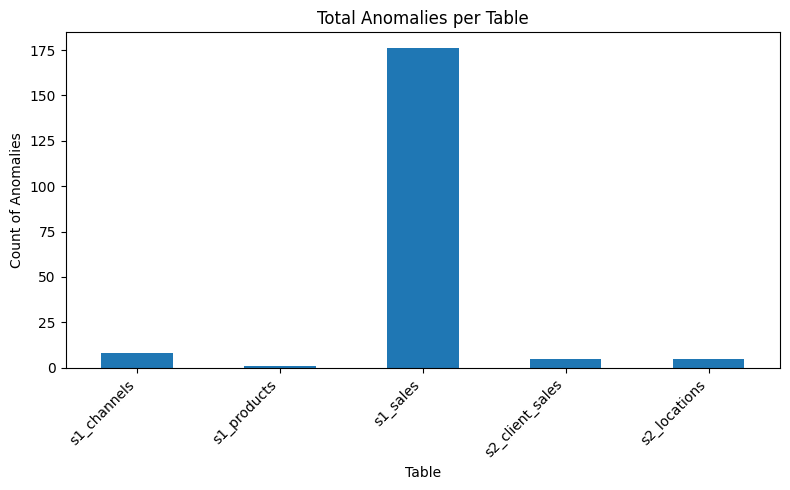

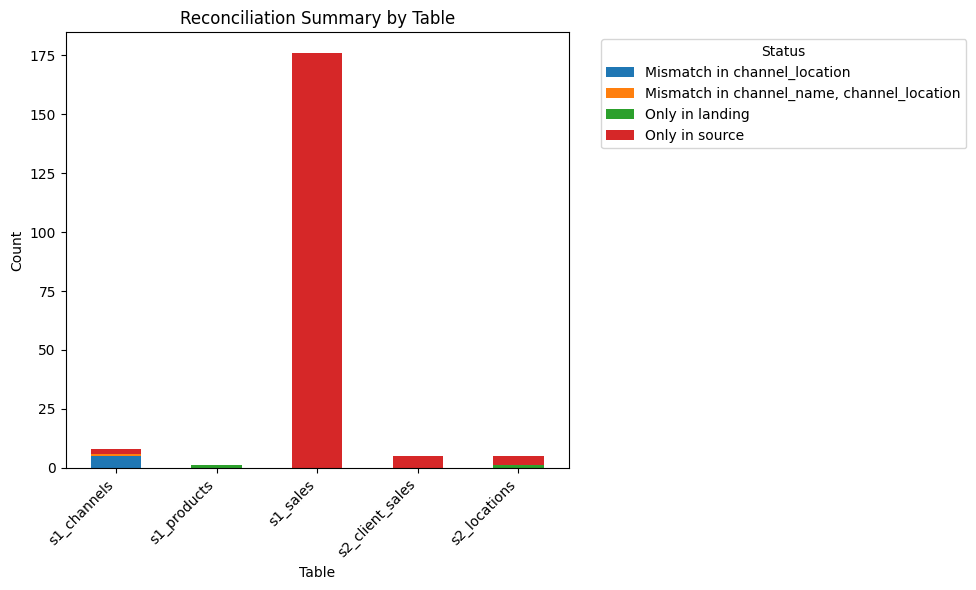

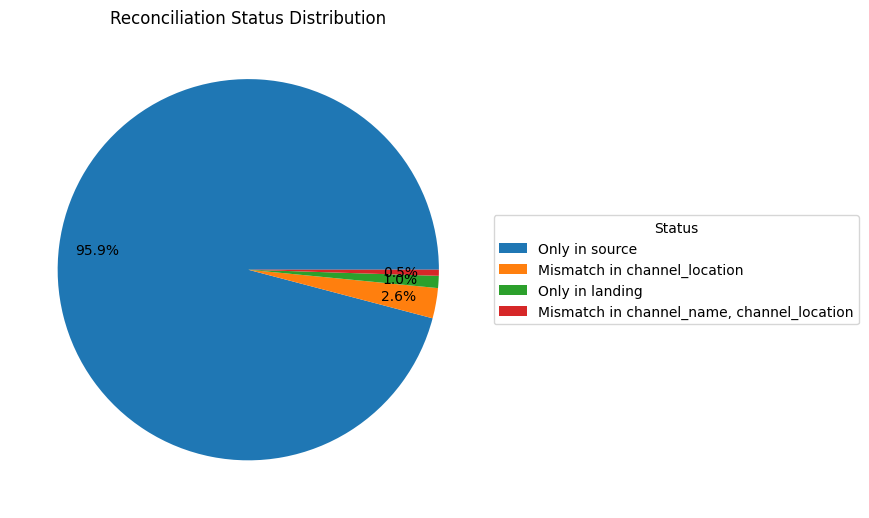

In [18]:
import matplotlib.pyplot as plt

# 1. Total Anomalies per Table
anomalies_per_table = final_result_df.groupby('table_name').size()
anomalies_per_table.plot(kind='bar', figsize=(8, 5), title='Total Anomalies per Table')
plt.ylabel('Count of Anomalies')
plt.xlabel('Table')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Reconciliation Summary by Table (status breakdown per table)
summary = final_result_df.groupby(['table_name', 'reconciliation_status']).size().unstack(fill_value=0)
summary.plot(kind='bar', stacked=True, figsize=(10, 6), title='Reconciliation Summary by Table')
plt.ylabel('Count')
plt.xlabel('Table')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. Reconciliation Status Distribution (overall, across all tables)
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(status_counts, autopct='%1.1f%%', pctdistance=0.8)
ax.set_title('Reconciliation Status Distribution')
ax.legend(wedges, status_counts.index, title="Status", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

